# Is MoMA's increasing representation of women artists driven by acquiring their work in real time, or by retroactively "correcting" the collection, i.e., acquiring older, previously-overlooked work by women decades after it was made?

In [10]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ipywidgets import interact
import json

In [2]:
df = pd.read_csv('Artworks.csv', encoding = 'utf-8-sig', low_memory = False)
df.shape

(62464, 30)

In [3]:
from pandas.tseries.offsets import YearBegin
import re
def split_parenthesized(value):
  if pd.isna(value):
    return[]
  s = value.strip()
  if s.startswith('(') and s.endswith(')'):
    s = s[1:-1]
  return re.split(r'\)\s*\(',s)
def first_or_nan(lst):
  if not lst or lst[0] == '':
    return np.nan
  return lst[0]
def extract_year(value):
  if pd.isna(value):
    return np.nan
  s = str(value)
  match = re.search(r'\d{4}', s)
  if not match:
      return np.nan
  year = int(match.group())
  if re.search(r'B\.?C\.?', s, re.IGNORECASE):
      year = -year
  return year

df['Gender_list'] = df['Gender'].apply(split_parenthesized)
df['Gender_primary'] = df['Gender_list'].apply(first_or_nan)

df['Year'] = df['Date'].apply(extract_year)
df['DateAcquired'] = pd.to_datetime(df['DateAcquired'],
                                    errors = 'coerce')
df['AcquisitionYear'] = df['DateAcquired'].dt.year
df['Lag'] = df['AcquisitionYear'] - df['Year']

subset = df[df['Gender_primary'].isin(['male','female']) &
            df['Lag'].notna()]
subset.groupby('Gender_primary')['Lag'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender_primary,,,,,,,,
female,5067.0,22.776396,24.363705,-10.0,2.0,12.0,41.0,131.0
male,54114.0,29.098385,30.245672,-14.0,4.0,20.0,46.0,196.0


In [4]:
print('Year missing:', df['Year'].isna().sum(), '/', len(df))
print('AcquisitionYear missing:',
      df['AcquisitionYear'].isna().sum(),'/', len(df))
print('Lag missing:', df['Lag'].isna().sum(),'/', len(df))
print()
print(df['Gender_primary'].value_counts(dropna=False).head(10))
print()
print('subset rows:', len(subset))

Year missing: 619 / 62464
AcquisitionYear missing: 392 / 62464
Lag missing: 1010 / 62464

Gender_primary
male                  54926
female                 5106
NaN                    2431
male (trans? ftm?)        1
Name: count, dtype: int64

subset rows: 59181


In [5]:
print(df['Date'].dtype)
print(df['Date'].head(10).tolist())
print()
print(extract_year(df['Date'].iloc[0]))
print(extract_year('1973'))

object
['1896', '1987', '1903', '1980', '1903', '1976-77', '1976-77', '1976-77', '1976-77', '1976-77']

1896
1973


In [6]:
neg_lag = subset[subset['Lag']<0]
print('Rows with negative lag:', len(neg_lag))
print(neg_lag['Gender_primary'].value_counts())
print()
neg_lag[['Title','Artist','Date','Year','DateAcquired','AcquisitionYear','Lag']].head()

Rows with negative lag: 20
Gender_primary
male      19
female     1
Name: count, dtype: int64



,Title,Artist,Date,Year,DateAcquired,AcquisitionYear,Lag
374,"First Unitarian Church and School, Rochester, ...",Louis I. Kahn,1969,1969.0,1967-04-11,1967.0,-2.0
438,"Les Eschelles du Baroque Apartment Building, P...",Ricardo Bofill,1987,1987.0,1985-11-18,1985.0,-2.0
1505,Expandable Containers,William N. Touzani,1987,1987.0,1986-05-16,1986.0,-1.0
4062,Help Prevent Despair. Care,George Delany,1987,1987.0,1986-05-16,1986.0,-1.0
4284,If You are Suffering from Scabies,Abram Games,c. 1944,1944.0,1943-05-12,1943.0,-1.0


In [7]:
print('Duplicate ObjectID rows:',
df['ObjectID'].duplicated().sum())

hashable_cols = [x for x in df.columns if not
x.endswith('_list')]
print('Fully duplicate rows:',
df[hashable_cols].duplicated().sum())


Duplicate ObjectID rows: 0
Fully duplicate rows: 0


In [8]:
subset = subset.copy()
subset['AcquisitionDecade'] = (subset['AcquisitionYear']//10) *10
subset['AcquisitionDecade'] = subset['AcquisitionDecade'].astype('Int64')
x = subset.groupby(['AcquisitionDecade',
                    'Gender_primary'])['Lag'].mean().unstack().round(1)
x

Gender_primary,female,male
AcquisitionDecade,,
1920,NaN,9.0
1930,9.4,13.5
1940,6.9,16.4
1950,16.1,18.6
1960,29.4,35.2
1970,23.3,22.8
1980,16.4,25.8
1990,22.6,26.8
2000,41.3,44.3


In [11]:
bins = list(range(-20, 105, 5))
hist_data = {}
for (decade, gender), group in subset.groupby(['AcquisitionDecade', 'Gender_primary']):
    clipped = group['Lag'].dropna().clip(bins[0], bins[-1] - 1)
    counts, _ = np.histogram(clipped, bins=bins)
    hist_data[f'{int(decade)}_{gender}'] = counts.tolist()

print(json.dumps({'bins': bins, 'data': hist_data}))

{"bins": [-20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100], "data": {"1920_male": [0, 0, 0, 0, 1, 4, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], "1930_female": [0, 0, 0, 0, 19, 6, 7, 4, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], "1930_male": [0, 1, 0, 0, 490, 187, 112, 65, 204, 11, 2, 36, 23, 14, 47, 3, 0, 3, 10, 6, 1, 0, 3, 0], "1940_female": [0, 0, 0, 0, 129, 62, 10, 4, 1, 7, 1, 4, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0], "1940_male": [0, 0, 0, 1, 1103, 446, 395, 296, 376, 270, 110, 99, 59, 46, 71, 31, 35, 4, 12, 4, 45, 5, 1, 7], "1950_female": [0, 0, 1, 0, 100, 33, 7, 5, 52, 24, 26, 11, 2, 2, 0, 5, 0, 0, 0, 0, 2, 2, 0, 0], "1950_male": [0, 0, 1, 3, 1448, 514, 266, 154, 197, 206, 331, 250, 136, 88, 128, 138, 64, 31, 6, 13, 3, 3, 1, 4], "1960_female": [0, 0, 0, 0, 236, 52, 41, 16, 21, 35, 57, 60, 16, 3, 6, 17, 20, 164, 5, 1, 0, 0, 1, 6], "1960_male": [0, 0, 0, 1, 4035, 1188, 1093, 2116, 1465, 889, 1641, 1464, 1722, 1424

In [12]:
pd.set_option('display.max_columns', 40)
df = pd.read_csv('Artworks.csv', encoding='utf-8-sig', low_memory=False)
df.shape
df.head()

,Title,Artist,ConstituentID,ArtistBio,Nationality,BeginDate,EndDate,Gender,Date,Medium,Dimensions,CreditLine,AccessionNumber,Classification,Department,DateAcquired,Cataloged,ObjectID,URL,ImageURL,OnView,Circumference (cm),Depth (cm),Diameter (cm),Height (cm),Length (cm),Weight (kg),Width (cm),Seat Height (cm),Duration (sec.)
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,"(Austrian, 1841–1918)",(Austrian),(1841),(1918),(male),1896,Ink and cut-and-pasted painted pages on paper,"19 1/8 x 66 1/2"" (48.6 x 168.9 cm)",Fractional and promised gift of Jo Carole and ...,885.1996,Architecture,Architecture & Design,1996-04-09,Y,2,https://www.moma.org/collection/works/2,https://www.moma.org/media/W1siZiIsIjUyNzc3MCJ...,NaN,NaN,NaN,NaN,48.6000,NaN,NaN,168.9000,NaN,NaN
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,"(French, born 1944)",(French),(1944),(0),(male),1987,Paint and colored pencil on print,"16 x 11 3/4"" (40.6 x 29.8 cm)",Gift of the architect in honor of Lily Auchinc...,1.1995,Architecture,Architecture & Design,1995-01-17,Y,3,https://www.moma.org/collection/works/3,https://www.moma.org/media/W1siZiIsIjUyNzM3NCJ...,NaN,NaN,NaN,NaN,40.6401,NaN,NaN,29.8451,NaN,NaN
2,"Villa project, outside Vienna, Austria (Elevat...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(male),1903,"Graphite, pen, color pencil, ink, and gouache ...","13 1/2 x 12 1/2"" (34.3 x 31.8 cm)",Gift of Jo Carole and Ronald S. Lauder,1.1997,Architecture,Architecture & Design,1997-01-15,Y,4,https://www.moma.org/collection/works/4,https://www.moma.org/media/W1siZiIsIjUyNzM3NSJ...,NaN,NaN,NaN,NaN,34.3000,NaN,NaN,31.8000,NaN,NaN
3,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,7056,"(French and Swiss, born Switzerland 1944)",(),(1944),(0),(male),1980,Photographic reproduction with colored synthet...,"20 x 20"" (50.8 x 50.8 cm)",Purchase and partial gift of the architect in ...,2.1995,Architecture,Architecture & Design,1995-01-17,Y,5,https://www.moma.org/collection/works/5,https://www.moma.org/media/W1siZiIsIjUyNzQ3NCJ...,NaN,NaN,NaN,NaN,50.8000,NaN,NaN,50.8000,NaN,NaN
4,"Villa project, outside Vienna, Austria (Exteri...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(male),1903,"Graphite, color pencil, ink, and gouache on tr...","15 1/8 x 7 1/2"" (38.4 x 19.1 cm)",Gift of Jo Carole and Ronald S. Lauder,2.1997,Architecture,Architecture & Design,1997-01-15,Y,6,https://www.moma.org/collection/works/6,https://www.moma.org/media/W1siZiIsIjUyNzQ3NSJ...,NaN,NaN,NaN,NaN,38.4000,NaN,NaN,19.1000,NaN,NaN


In [13]:
df.dtypes

,0
Title,object
Artist,object
ConstituentID,object
ArtistBio,object
Nationality,object
BeginDate,object
EndDate,object
Gender,object
Date,object
Medium,object


In [14]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing.round(1)

,0
Seat Height (cm),100.0
Circumference (cm),100.0
Weight (kg),99.8
Length (cm),99.5
OnView,99.2
Diameter (cm),99.1
Duration (sec.),98.8
Depth (cm),88.3
ImageURL,40.7
URL,35.3


In [15]:
df['Classification'].value_counts().head(15)

,count
Classification,
Photograph,35050
Print,33373
Illustrated Book,28352
Mies van der Rohe Archive,17092
Drawing,14369
Design,12041
Architecture,4568
Painting,2453
Video,2445


In [16]:
df['Department'].value_counts()

,count
Department,
Drawings & Prints,82220
Architecture & Design,34539
Photography,33825
Painting & Sculpture,4093
Media and Performance,3295
Fluxus Collection,1683
Film,1019
Architecture & Design - Image Archive,31


In [17]:
df['DateAcquired'] = pd.to_datetime(df['DateAcquired'],
                                    errors = 'coerce')
df['DateAcquired'].min(),
df['DateAcquired'].max(),
df['DateAcquired'].isna().sum()


np.int64(5468)

In [18]:
df['Gender'].value_counts(dropna=False).head(20)

,count
Gender,
(male),123606
(female),20247
(),7363
(male) (male),1755
NaN,1258
(male) (male) (male),1066
(male) (female),963
(male) (),896
() (male),515


In [19]:
print('Missing Classification (before):',
df['Classification'].isna().sum()) # measurement 1, before the fix

df['Classification'] = df['Classification'].replace('(not assigned)',
                                                   np.nan) #the actual fix
print('Missing Classification (after):',
df['Classification'].isna().sum()) # measurement 2, after the fix

Missing Classification (before): 1
Missing Classification (after): 687


In [20]:
df.to_csv('artworks_clean.csv', index=False)
print('Saved',len(df), 'rows')

Saved 160705 rows


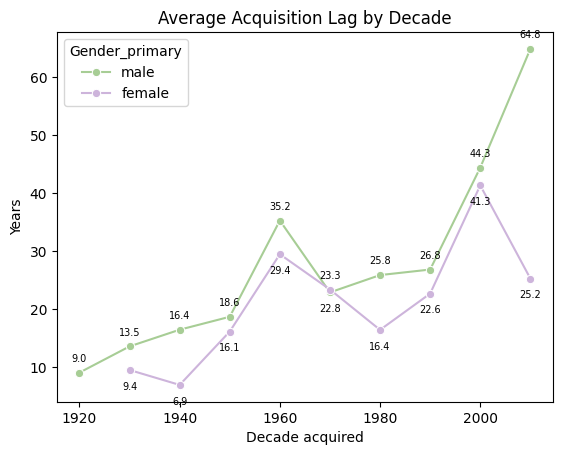

In [21]:
long_data = subset.groupby(['AcquisitionDecade',
                            'Gender_primary'])['Lag'].mean().reset_index()

sns.lineplot(data = long_data, x = 'AcquisitionDecade',
             y = 'Lag', hue='Gender_primary',
             marker = 'o', palette = {'male': '#A7CD95', 'female': '#cdb4db'})
plt.xlabel('Decade acquired')
plt.ylabel('Years')
plt.title('Average Acquisition Lag by Decade')

for _, row in long_data.iterrows():
  decade = row['AcquisitionDecade']
  other_gender = 'female' if row['Gender_primary'] == 'male' else 'male'
  other_value = x.loc[decade,other_gender]

  if pd.isna(other_value) or row['Lag'] >= other_value:
    offset = 8
  else: offset = -14
  plt.annotate(f"{row['Lag']:.1f}", (decade, row['Lag']),
               textcoords = "offset points", xytext = (0,offset),
              ha='center', fontsize = 7)
plt.show()

In [22]:
def lag_calculator(year_created = 1975, year_acquired = 1990):
  lag = year_acquired - year_created
  print(f"Lag = {year_acquired}-{year_created} = {lag} years")
interact(lag_calculator,year_created = (1800,2026),
         year_acquired = (1800,2026));

interactive(children=(IntSlider(value=1975, description='year_created', max=2026, min=1800), IntSlider(value=1…

In [54]:
def decade_gap(decade = 2020):
 male_row = long_data[(long_data['AcquisitionDecade'] == decade) & (long_data['Gender_primary'] == 'male')]
 female_row = long_data[(long_data['AcquisitionDecade'] == decade) & (long_data['Gender_primary'] == 'female')]
 male_val = male_row['Lag'].values[0] if len(male_row) > 0 else None
 female_val = female_row['Lag'].values[0] if len(female_row) > 0 else None
 if female_val is None:
   print(f"{decade}s: no female - attributed acquisitions. Male average: {male_val:.1f} years")
 else:
  gap = female_val - male_val
  print(f"{decade}s - Male: {male_val:.1f} yrs,Female: {female_val:.1f} yrs, Gap (F-M): {gap:+.1f} yrs")
interact(decade_gap, decade = sorted(long_data['AcquisitionDecade'].unique()));



interactive(children=(Dropdown(description='decade', options=(np.int64(1920), np.int64(1930), np.int64(1940), …

## Conclusion

**Research question:** Is MoMA's increasing representation of women artists driven by acquiring their work in real time, or by retroactively "correcting" the collection, i.e., acquiring older, previously-overlooked work by women decades after it was made?

**Finding:** The data points away from retroactive correction. Of the 160,705 artworks in the cleaned dataset, 142,505 have both a usable creation year, acquisition date, and a gender recorded as exactly "male" or "female." Within that group, women's work is acquired sooner after it is made than men's work, not later. The average gap is about 5.7 years (22.9 years for women vs. 28.6 years for men). This holds true in almost every decade from the 1930s to the 2020s. Only the 1970s is close to even. If MoMA were mainly catching up on overlooked women artists years after the fact, we would expect the opposite pattern, a longer wait for women, not a shorter one.

**Nuance:** Acquisition lag has grown for both men and women over time. In the 1920s and 1930s, MoMA acquired art within about 10 years of it being made. Today that gap is 30 to 50 years for both genders. The gender difference sits on top of this larger trend, it does not replace it.

**Limitations:** 18,200 artworks are excluded from this analysis, either because the creation year or acquisition date could not be determined, or because gender was missing or recorded as something other than exactly "male" or "female." Among the artworks that are included, men outnumber women roughly 6 to 1, and even more so before 1960. The 1920s has no acquisitions by women at all. A small number of records, 93 out of 142,505, show an artwork acquired slightly before its listed creation date, almost always because the creation date itself is approximate.

**What this doesn't prove:** This shows a pattern, not a cause. We don't know why the gap exists; it could reflect deliberate MoMA acquisition strategy, market dynamics (contemporary women artists may be more visible/collectible sooner than in past decades), differences in which works get gender-attributed in the dataset, or something else entirely. This analysis can't distinguish between those explanations.